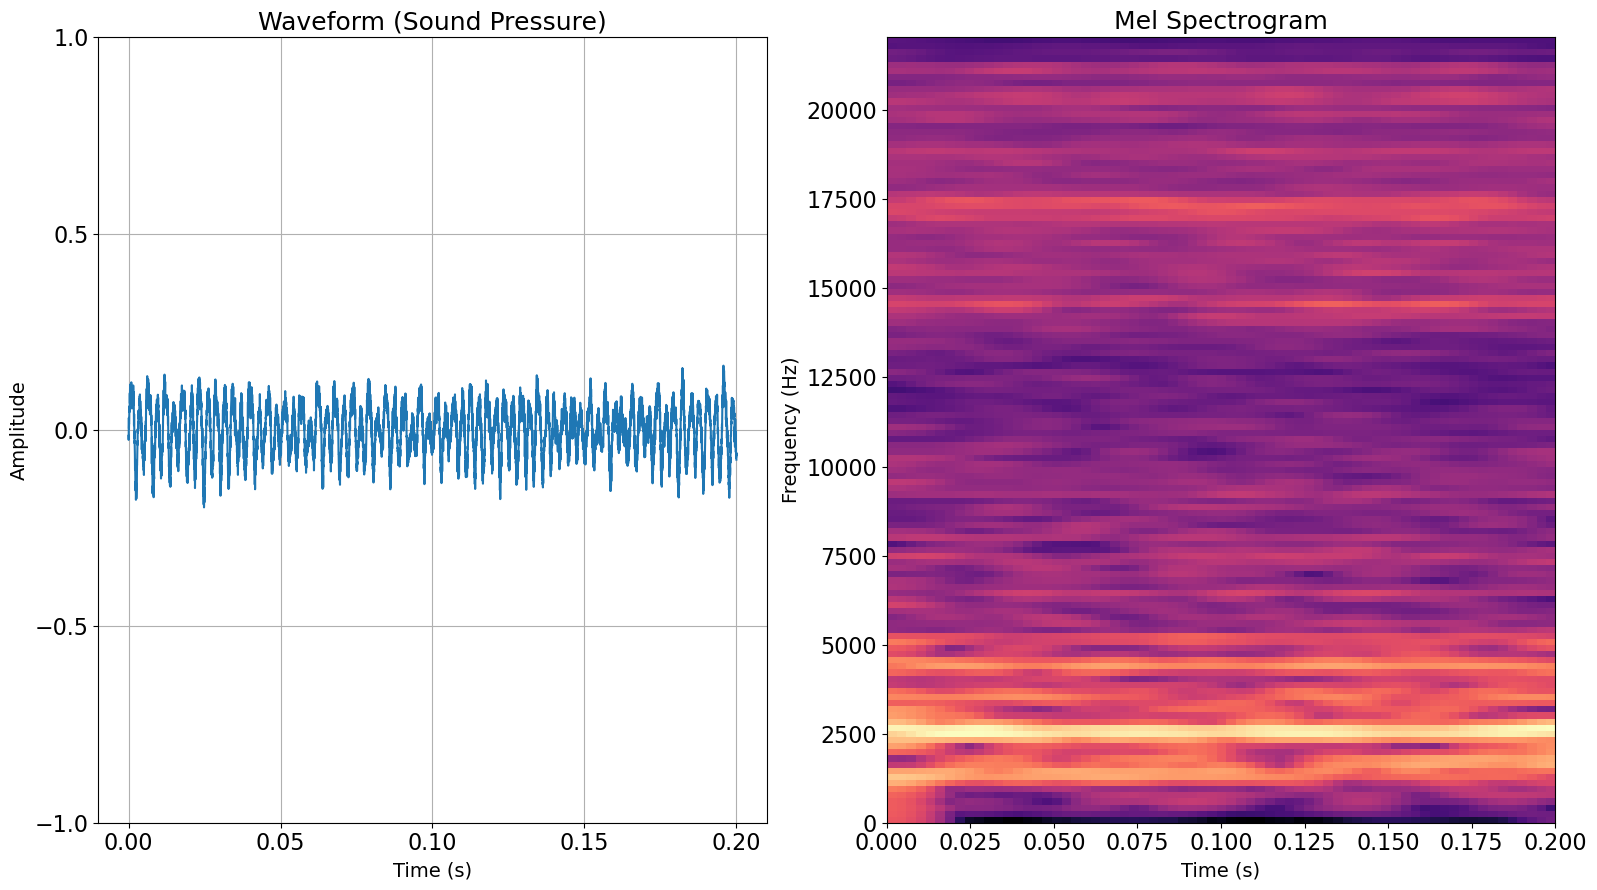

In [62]:
import torch
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt

# ----------------------------------------------------
# 1. 오디오 파일 불러오기
# ----------------------------------------------------
# 파일 경로를 실제 파일로 변경하세요.
file_path = '../data/inspection/ground_inspection/idling/audio/ground_idling.wav'

# torchaudio.load는 (waveform, sample_rate) 튜플을 반환합니다.
# waveform은 PyTorch 텐서(Tensor) 형태입니다.
waveform, sample_rate = torchaudio.load(file_path)

# 스테레오(채널 2개)인 경우, 모노(채널 1개)로 변환
if waveform.shape[0] > 1:
    waveform = torch.mean(waveform, dim=0, keepdim=True)

# ----------------------------------------------------
# 2. 멜 스펙트로그램 계산
# ----------------------------------------------------
# 멜 스펙트로그램을 계산하기 위한 변환(transform) 객체 생성
mel_spectrogram_transform = T.MelSpectrogram(
    sample_rate=sample_rate,
    n_fft=4096,          # 주파수 해상도 높임
    hop_length=128,      # 시간 해상도 높임
    n_mels=128,          # 멜 밴드(Y축 해상도) 개수 늘림
    win_length=2048,
    window_fn=torch.hann_window
)

# waveform에 변환을 적용하여 멜 스펙트로그램 계산
mel_spectrogram = mel_spectrogram_transform(waveform)

# ----------------------------------------------------
# 3. 데시벨(dB) 스케일로 변환
# ----------------------------------------------------
# 시각화를 위해 진폭(amplitude)을 데시벨로 변환
amplitude_to_db_transform = T.AmplitudeToDB()
mel_spectrogram_db = amplitude_to_db_transform(mel_spectrogram)

# ----------------------------------------------------
# 4. 그래프 시각화
# ----------------------------------------------------
# matplotlib으로 그래프를 그리기 위해 텐서를 numpy 배열로 변환
waveform_np = waveform.squeeze().numpy()
mel_spectrogram_db_np = mel_spectrogram_db.squeeze().numpy()

# 시간 축 생성을 위해 오디오 샘플 수를 이용
num_frames = waveform.shape[1]
time_axis = torch.linspace(0, num_frames / sample_rate, steps=num_frames)

# 두 개의 그래프를 위아래로 배치
fig, axs = plt.subplots(1, 2, figsize=(16, 9))

# 첫 번째 그래프: 음압 (Waveform)
axs[0].plot(time_axis, waveform_np)
axs[0].set_ylim([-1, 1])  # Y축 범위를 -1에서 1로 고정
axs[0].set_title('Waveform (Sound Pressure)',fontsize=18)
axs[0].set_xlabel('Time (s)', fontsize=14)
axs[0].set_ylabel('Amplitude', fontsize=14)
axs[0].grid(True)
axs[0].tick_params(axis='both', labelsize=16)
axs[0].set_yticks([-1.0, -0.5, 0, 0.5, 1.0])
axs[0].set_xticks([0.00, 0.05, 0.10, 0.15, 0.20])

# 두 번째 그래프: 멜 스펙트로그램
# imshow를 사용하여 스펙트로그램을 이미지로 표시
im = axs[1].imshow(mel_spectrogram_db_np, aspect='auto', origin='lower', cmap='magma',
                   extent=[time_axis[0], time_axis[-1], 0, sample_rate / 2])
axs[1].set_title('Mel Spectrogram', fontsize=18)
axs[1].set_xlabel('Time (s)', fontsize=14)
axs[1].set_ylabel('Frequency (Hz)', fontsize=14)
axs[1].tick_params(axis='both', labelsize=16)

# 컬러바 추가
# fig.colorbar(im, ax=axs[1], format='%+2.0f dB', label='Intensity (dB)')

# 레이아웃 최적화 및 그래프 표시
plt.tight_layout()
plt.show()